# Chapter 60 — Single-Head Self-Attention From Scratch

## Learning goals

By the end of this chapter, you should be able to:

- Explain why the operation is called single-head self-attention.

- Project input vectors into query, key, and value vectors.

- Compute and scale every query-key score.

- Apply causal masking and row-wise softmax.

- Use attention weights to mix value vectors.

- Track every major tensor shape.

- Implement the score and output calculations with explicit loops.

- Implement the same calculations with matrix multiplication.

- Build a reusable PyTorch attention module that accepts unbatched or batched input.

- Explain why self-attention returns one output vector per input position.


## One complete attention head

The previous chapters developed weighted averaging, query-key scores, causal masking, and softmax separately.

A **self-attention** operation gets its queries, keys, and values from the same input sequence.

A **single head** uses one query projection, one key projection, and one value projection to produce one attention pattern.

Causal self-attention follows this ordered process:

1. Project every input vector into a query, key, and value vector.

2. Use scaled query-key dot products to score every pair of positions.

3. Mask future positions and apply softmax across allowed source positions.

4. Use those weights to average the value vectors for every receiving position.

> Self-attention preserves the sequence dimension instead of reducing the entire sequence to one vector.


## Dimensions in this example

We use the sequence `"the cat sat"` and hand-written token-position vectors so every number remains inspectable.

The **input dimension** is the number of features in each input vector.

The **query-key dimension** is the shared feature count required for query-key dot products.

The **value dimension** is the feature count of each value vector and therefore of each head output vector.

Our small head uses dimension `2` for queries, keys, and values, although the value dimension does not have to equal the query-key dimension in the general formula.


The first code cell creates the sequence and its input vectors.


In [1]:
import torch

device = "cpu"
tokens = ["the", "cat", "sat"]

input_vectors = torch.tensor(
    [
        [1.0, 0.0, 0.0, 0.5],
        [0.0, 1.0, 0.0, 0.5],
        [0.0, 0.0, 1.0, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)

sequence_length, input_dimension = input_vectors.shape

print("device:", device)
print("tokens:", tokens)
print("input_vectors:")
print(input_vectors)
print("input_vectors.shape:", input_vectors.shape)

device: cpu
tokens: ['the', 'cat', 'sat']
input_vectors:
tensor([[1.0000, 0.0000, 0.0000, 0.5000],
        [0.0000, 1.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 1.0000, 0.5000]])
input_vectors.shape: torch.Size([3, 4])


The input has shape `[sequence length, input dimension]`, or `[3, 4]`.

Each row represents one token at one sequence position.


## Query, key, and value projections

Three separate projection matrices give matching and information transfer different learned representations.

These matrices are fixed teaching values, while a trained model learns them as parameters.


In [2]:
query_projection_matrix = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 0.5],
        [0.0, 0.0],
        [0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)
key_projection_matrix = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 1.0],
        [0.0, 0.5],
        [0.5, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)
value_projection_matrix = torch.tensor(
    [
        [0.5, 0.0],
        [0.0, 1.0],
        [1.0, 0.0],
        [0.0, 0.5],
    ],
    dtype=torch.float32,
    device=device,
)

print("query projection shape:", query_projection_matrix.shape)
print("key projection shape:", key_projection_matrix.shape)
print("value projection shape:", value_projection_matrix.shape)

query projection shape: torch.Size([4, 2])
key projection shape: torch.Size([4, 2])
value projection shape: torch.Size([4, 2])


Each matrix has shape `[input dimension, projected dimension]`, or `[4, 2]`.

Multiplying every input row by each matrix produces one query, key, and value row per position.


In [3]:
query_vectors = input_vectors @ query_projection_matrix
key_vectors = input_vectors @ key_projection_matrix
value_vectors = input_vectors @ value_projection_matrix

print("position | token | query       | key         | value")
print("-" * 71)
for position, token in enumerate(tokens):
    print(
        f"{position:>8} | {token:>5} | "
        f"{str(query_vectors[position].tolist()):>11} | "
        f"{str(key_vectors[position].tolist()):>11} | "
        f"{value_vectors[position].tolist()}"
    )

print()
print("query_vectors.shape:", query_vectors.shape)
print("key_vectors.shape:", key_vectors.shape)
print("value_vectors.shape:", value_vectors.shape)

position | token | query       | key         | value
-----------------------------------------------------------------------
       0 |   the | [1.25, 0.25] | [1.25, 0.25] | [0.5, 0.25]
       1 |   cat | [0.25, 0.75] | [0.25, 1.25] | [0.0, 1.25]
       2 |   sat | [0.25, 0.25] | [0.25, 0.75] | [1.0, 0.25]

query_vectors.shape: torch.Size([3, 2])
key_vectors.shape: torch.Size([3, 2])
value_vectors.shape: torch.Size([3, 2])


All three tensors have one row per position.

Queries and keys determine the attention weights, but values provide the vectors that those weights will mix.


## Pairwise scores: loops and matrices

The loop implementation exposes the meaning of entry `[i, j]`: the query from receiving position `i` dotted with the key from source position `j`.

Matrix multiplication computes the same pairwise scores in one operation.


In [4]:
manual_attention_scores = torch.zeros(
    sequence_length,
    sequence_length,
    dtype=input_vectors.dtype,
    device=device,
)

for receiving_position in range(sequence_length):
    for source_position in range(sequence_length):
        manual_attention_scores[receiving_position, source_position] = torch.dot(
            query_vectors[receiving_position],
            key_vectors[source_position],
        )

matrix_attention_scores = query_vectors @ key_vectors.transpose(-2, -1)

print("manual scores:")
print(manual_attention_scores)
print("matrix scores:")
print(matrix_attention_scores)
print(
    "methods match:",
    torch.allclose(manual_attention_scores, matrix_attention_scores),
)
print("score table shape:", matrix_attention_scores.shape)

manual scores:
tensor([[1.6250, 0.6250, 0.5000],
        [0.5000, 1.0000, 0.6250],
        [0.3750, 0.3750, 0.2500]])
matrix scores:
tensor([[1.6250, 0.6250, 0.5000],
        [0.5000, 1.0000, 0.6250],
        [0.3750, 0.3750, 0.2500]])
methods match: True
score table shape: torch.Size([3, 3])


Both methods produce the same `[sequence length, sequence length]` score table.

Python loops make the pairwise definition visible, while matrix multiplication is the compact operation used in model implementations.


## Scale, mask, and normalize

Scaled dot-product attention divides every score by the square root of the query-key dimension.

This keeps typical dot products from growing solely because queries and keys have many features.

After scaling, the causal mask blocks future columns and softmax converts every row into a distribution over allowed source positions.


In [5]:
import math

query_key_dimension = query_vectors.shape[-1]
scaled_attention_scores = matrix_attention_scores / math.sqrt(query_key_dimension)

causal_mask = torch.tril(
    torch.ones(
        sequence_length,
        sequence_length,
        dtype=torch.bool,
        device=device,
    )
)
masked_attention_scores = scaled_attention_scores.masked_fill(
    ~causal_mask,
    float("-inf"),
)
attention_weights = torch.softmax(masked_attention_scores, dim=-1)

print("scale divisor:", math.sqrt(query_key_dimension))
print("scaled scores:")
print(scaled_attention_scores)
print("masked scores:")
print(masked_attention_scores)
print("attention weights:")
print(attention_weights)
print("row sums:", attention_weights.sum(dim=-1))
print("future weights:", attention_weights[~causal_mask])

scale divisor: 1.4142135623730951
scaled scores:
tensor([[1.1490, 0.4419, 0.3536],
        [0.3536, 0.7071, 0.4419],
        [0.2652, 0.2652, 0.1768]])
masked scores:
tensor([[1.1490,   -inf,   -inf],
        [0.3536, 0.7071,   -inf],
        [0.2652, 0.2652, 0.1768]])
attention weights:
tensor([[1.0000, 0.0000, 0.0000],
        [0.4125, 0.5875, 0.0000],
        [0.3430, 0.3430, 0.3140]])
row sums: tensor([1., 1., 1.])
future weights: tensor([0., 0., 0.])


The diagonal guarantees at least one allowed source per row.

Every row sums to `1`, and every future position has weight `0`.

The score and weight tables both keep shape `[sequence length, sequence length]`.


## Weighted value mixtures

Each receiving position now needs a weighted average of the source value vectors.

The loop adds one weighted value contribution at a time, while `attention_weights @ value_vectors` computes every output row together.


In [6]:
value_dimension = value_vectors.shape[-1]
manual_attention_output = torch.zeros(
    sequence_length,
    value_dimension,
    dtype=input_vectors.dtype,
    device=device,
)

for receiving_position in range(sequence_length):
    for source_position in range(sequence_length):
        manual_attention_output[receiving_position] += (
            attention_weights[receiving_position, source_position]
            * value_vectors[source_position]
        )

matrix_attention_output = attention_weights @ value_vectors

print("manual output:")
print(manual_attention_output)
print("matrix output:")
print(matrix_attention_output)
print(
    "methods match:",
    torch.allclose(manual_attention_output, matrix_attention_output),
)
print("output shape:", matrix_attention_output.shape)

manual output:
tensor([[0.5000, 0.2500],
        [0.2063, 0.8375],
        [0.4855, 0.5930]])
matrix output:
tensor([[0.5000, 0.2500],
        [0.2063, 0.8375],
        [0.4855, 0.5930]])
methods match: True
output shape: torch.Size([3, 2])


The output has shape `[sequence length, value dimension]`, or `[3, 2]`.

Its three rows are new vectors for `"the"`, `"cat"`, and `"sat"`, respectively.

The operation averages value vectors, not query or key vectors.


The following trace shows how the three weighted value contributions form the output for `"sat"`.


In [7]:
sat_position = tokens.index("sat")
sat_contributions = attention_weights[sat_position].unsqueeze(dim=-1) * value_vectors

print("source | weight   | value        | weighted contribution")
print("-" * 66)
for source_token, weight, value_vector, contribution in zip(
    tokens,
    attention_weights[sat_position],
    value_vectors,
    sat_contributions,
    strict=True,
):
    print(
        f"{source_token:>6} | {weight.item():>8.6f} | "
        f"{str(value_vector.tolist()):>12} | {contribution.tolist()}"
    )

print("sum of contributions:", sat_contributions.sum(dim=0))

source | weight   | value        | weighted contribution
------------------------------------------------------------------
   the | 0.343005 |  [0.5, 0.25] | [0.1715027391910553, 0.08575136959552765]
   cat | 0.343005 |  [0.0, 1.25] | [0.0, 0.42875683307647705]
   sat | 0.313989 |  [1.0, 0.25] | [0.3139890134334564, 0.0784972533583641]
sum of contributions: tensor([0.4855, 0.5930])


The sum equals the last row of the attention output.

Earlier receiving positions use fewer source values because causal masking assigns their future contributions weight `0`.


This heatmap summarizes the three attention distributions and makes the causal zeros visible.


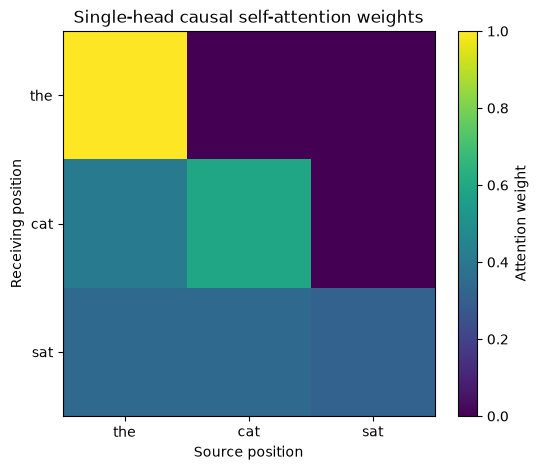

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(attention_weights.detach(), aspect="auto", vmin=0.0, vmax=1.0)
plt.colorbar(label="Attention weight")
plt.xticks(range(sequence_length), tokens)
plt.yticks(range(sequence_length), tokens)
plt.xlabel("Source position")
plt.ylabel("Receiving position")
plt.title("Single-head causal self-attention weights")
plt.show()

The zeros above the diagonal show that no receiving position uses information from a future source position.


## Reusable loop and matrix functions

The next cell packages the derivation into two functions with the same contract.

The loop version accepts one unbatched sequence for clarity, while the matrix version also supports leading batch dimensions.


In [9]:
def causal_self_attention_with_loops(
    input_vectors: torch.Tensor,
    query_projection_matrix: torch.Tensor,
    key_projection_matrix: torch.Tensor,
    value_projection_matrix: torch.Tensor,
) -> torch.Tensor:
    if input_vectors.ndim != 2:
        raise ValueError("the loop version expects [sequence, input features].")

    queries = input_vectors @ query_projection_matrix
    keys = input_vectors @ key_projection_matrix
    values = input_vectors @ value_projection_matrix

    if queries.shape[-1] != keys.shape[-1]:
        raise ValueError("query and key dimensions must match.")

    length = input_vectors.shape[0]
    scores = torch.zeros(
        length, length, dtype=input_vectors.dtype, device=input_vectors.device
    )
    for receiving_position in range(length):
        for source_position in range(length):
            scores[receiving_position, source_position] = torch.dot(
                queries[receiving_position], keys[source_position]
            )

    scores = scores / math.sqrt(queries.shape[-1])
    allowed = torch.tril(
        torch.ones(length, length, dtype=torch.bool, device=input_vectors.device)
    )
    weights = torch.softmax(scores.masked_fill(~allowed, float("-inf")), dim=-1)

    output = torch.zeros(
        length,
        values.shape[-1],
        dtype=input_vectors.dtype,
        device=input_vectors.device,
    )
    for receiving_position in range(length):
        for source_position in range(length):
            output[receiving_position] += (
                weights[receiving_position, source_position] * values[source_position]
            )

    return output


def causal_self_attention_with_matrices(
    input_vectors: torch.Tensor,
    query_projection_matrix: torch.Tensor,
    key_projection_matrix: torch.Tensor,
    value_projection_matrix: torch.Tensor,
) -> torch.Tensor:
    queries = input_vectors @ query_projection_matrix
    keys = input_vectors @ key_projection_matrix
    values = input_vectors @ value_projection_matrix

    if queries.shape[-1] != keys.shape[-1]:
        raise ValueError("query and key dimensions must match.")

    scores = queries @ keys.transpose(-2, -1)
    scores = scores / math.sqrt(queries.shape[-1])
    length = input_vectors.shape[-2]
    allowed = torch.tril(
        torch.ones(length, length, dtype=torch.bool, device=input_vectors.device)
    )
    weights = torch.softmax(scores.masked_fill(~allowed, float("-inf")), dim=-1)

    return weights @ values


loop_output = causal_self_attention_with_loops(
    input_vectors,
    query_projection_matrix,
    key_projection_matrix,
    value_projection_matrix,
)
matrix_output = causal_self_attention_with_matrices(
    input_vectors,
    query_projection_matrix,
    key_projection_matrix,
    value_projection_matrix,
)

print("loop output:")
print(loop_output)
print("matrix output:")
print(matrix_output)
print("functions match:", torch.allclose(loop_output, matrix_output))

loop output:
tensor([[0.5000, 0.2500],
        [0.2063, 0.8375],
        [0.4855, 0.5930]])
matrix output:
tensor([[0.5000, 0.2500],
        [0.2063, 0.8375],
        [0.4855, 0.5930]])
functions match: True


The functions reproduce the earlier result.

The matrix expression preserves the conceptual steps while allowing PyTorch to handle pairwise products efficiently.


## A trainable PyTorch module

A real model stores its projections as trainable `Linear` layers and its fixed causal mask as a non-trainable buffer.

The module below accepts input shaped `[..., sequence length, input dimension]`, where leading dimensions can include a batch.


In [10]:
class SingleHeadCausalSelfAttention(torch.nn.Module):
    input_dimension: int
    head_size: int
    context_length: int
    query_projection: torch.nn.Linear
    key_projection: torch.nn.Linear
    value_projection: torch.nn.Linear
    causal_mask: torch.Tensor

    def __init__(
        self,
        input_dimension: int,
        head_size: int,
        context_length: int,
    ) -> None:
        super().__init__()

        if input_dimension < 1 or head_size < 1 or context_length < 1:
            raise ValueError("all dimensions must be positive.")

        self.input_dimension = input_dimension
        self.head_size = head_size
        self.context_length = context_length
        self.query_projection = torch.nn.Linear(input_dimension, head_size, bias=False)
        self.key_projection = torch.nn.Linear(input_dimension, head_size, bias=False)
        self.value_projection = torch.nn.Linear(input_dimension, head_size, bias=False)

        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_vectors: torch.Tensor) -> torch.Tensor:
        if input_vectors.ndim < 2:
            raise ValueError("input_vectors must end with [sequence, input features].")

        if input_vectors.shape[-1] != self.input_dimension:
            raise ValueError("the input feature dimension is incorrect.")

        sequence_length = input_vectors.shape[-2]
        if sequence_length > self.context_length:
            raise ValueError("sequence length exceeds the configured context length.")

        queries = self.query_projection(input_vectors)
        keys = self.key_projection(input_vectors)
        values = self.value_projection(input_vectors)
        scores = queries @ keys.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_size)
        allowed = self.causal_mask[:sequence_length, :sequence_length]
        weights = torch.softmax(scores.masked_fill(~allowed, float("-inf")), dim=-1)

        return weights @ values


attention_head = SingleHeadCausalSelfAttention(
    input_dimension=input_dimension,
    head_size=query_key_dimension,
    context_length=sequence_length,
).to(device)

print(attention_head)
print("named parameters:")
for name, parameter in attention_head.named_parameters():
    print(" ", name, parameter.shape)
print("named buffers:")
for name, buffer in attention_head.named_buffers():
    print(" ", name, buffer.shape, buffer.dtype)

SingleHeadCausalSelfAttention(
  (query_projection): Linear(in_features=4, out_features=2, bias=False)
  (key_projection): Linear(in_features=4, out_features=2, bias=False)
  (value_projection): Linear(in_features=4, out_features=2, bias=False)
)
named parameters:
  query_projection.weight torch.Size([2, 4])
  key_projection.weight torch.Size([2, 4])
  value_projection.weight torch.Size([2, 4])
named buffers:
  causal_mask torch.Size([3, 3]) torch.bool


The projection weights are trainable parameters, while the Boolean causal mask moves with the module without receiving gradient updates.

For this teaching module, the value dimension equals `head_size`, so its output ends in that dimension.


PyTorch stores a `Linear` layer's weight as `[output features, input features]`, which is the transpose of our hand-written `[input features, output features]` matrices.

Copying the transposed matrices lets us verify the module against the from-scratch calculation and then test batching.


In [11]:
with torch.no_grad():
    attention_head.query_projection.weight.copy_(
        query_projection_matrix.transpose(0, 1)
    )
    attention_head.key_projection.weight.copy_(key_projection_matrix.transpose(0, 1))
    attention_head.value_projection.weight.copy_(
        value_projection_matrix.transpose(0, 1)
    )

module_output = attention_head(input_vectors)
batched_input_vectors = torch.stack(
    [input_vectors, input_vectors + 0.1],
    dim=0,
)
batched_output = attention_head(batched_input_vectors)

print("module output:")
print(module_output)
print(
    "module matches from-scratch output:",
    torch.allclose(module_output, matrix_attention_output),
)
print("batched input shape:", batched_input_vectors.shape)
print("batched output shape:", batched_output.shape)

module output:
tensor([[0.5000, 0.2500],
        [0.2063, 0.8375],
        [0.4855, 0.5930]], grad_fn=<MmBackward0>)
module matches from-scratch output: True
batched input shape: torch.Size([2, 3, 4])
batched output shape: torch.Size([2, 3, 2])


The unbatched module output exactly matches the earlier matrix result.

The batched output has shape `[batch size, sequence length, head size]`, so each sequence retains one output row per position.


## Shape summary

For one unbatched sequence in this example:

| Tensor | General shape | Example shape |
|---|---:|---:|
| Input vectors | sequence × input dimension | 3 × 4 |
| Query vectors | sequence × query-key dimension | 3 × 2 |
| Key vectors | sequence × query-key dimension | 3 × 2 |
| Value vectors | sequence × value dimension | 3 × 2 |
| Scores and weights | receiving sequence × source sequence | 3 × 3 |
| Attention output | sequence × value dimension | 3 × 2 |

The middle score table compares every receiving position with every source position.

The final multiplication removes only the source-position axis and leaves the receiving-position axis intact.


## Common mistakes

- **Collapsing the sequence:** self-attention returns one output vector for every receiving position.

- **Scaling by the wrong dimension:** the divisor is the square root of the query-key dimension, not the sequence length.

- **Averaging keys instead of values:** keys determine matches, while values supply output information.

- **Masking after softmax:** future scores must become negative infinity before normalization.

- **Using the wrong softmax axis:** each receiving-position row needs a distribution across source positions.

- **Reversing query and key axes:** score entry `[i, j]` uses query `i` and key `j`.

- **Exceeding the stored mask:** a module with maximum context length `T` must reject sequences longer than `T` or use a larger mask.


## Takeaways

- Self-attention derives queries, keys, and values from the same sequence.

- One head creates one scaled query-key score table and one corresponding attention pattern.

- Causal masking and row-wise softmax turn scores into distributions over allowed source positions.

- Attention weights mix value vectors to produce one new vector per receiving position.

- Explicit loops and matrix multiplication implement the same mathematics.

- A batched head preserves both the batch dimension and the sequence dimension.

> Attention updates every position; it does not summarize the entire sequence into one vector.


## What comes next

A single head learns one set of query, key, and value projections.

The next chapter introduces multi-head attention, where several heads learn different attention patterns in parallel and their outputs are combined.
